# UTS Soft Computing - Tahap 1

## Install & Import Library

In [1]:
!pip install scikit-fuzzy matplotlib numpy pandas seaborn tqdm

import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Semua library berhasil diimport!


## Load & Eksplorasi Dataset

In [2]:
df = pd.read_csv("../data/credit_risk_dataset.csv")

print("=== INFO DATASET ===")
print(f"Shape: {df.shape}")
print(f"\nKolom: {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDistribusi Kolom [loan_status]:\n{df['loan_status'].value_counts()}")

print("\n=== TAMPILAN DATASET ===")
df.head()

=== INFO DATASET ===
Shape: (32581, 12)

Kolom: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Distribusi Kolom [loan_status]:
loan_status
0    25473
1     7108
Name: count, dtype: int64

=== TAMPILAN DATASET ===


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Preprocessing & Cleaning

In [3]:
df_clean = df.copy()

# Hapus outlier ekstrem (usia > 80 dan emp_length > 60 tidak realistis)
df_clean = df_clean[df_clean['person_age'] <= 80]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]

# Isi missing values dengan median
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"Shape setelah cleaning: {df_clean.shape}\n")
print(f"Missing values setelah cleaning:\n{df_clean.isnull().sum()}")
print(f"\nDistribusi loan_status:\n{df_clean['loan_status'].value_counts()}")

Shape setelah cleaning: (31677, 12)

Missing values setelah cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Distribusi loan_status:
loan_status
0    24852
1     6825
Name: count, dtype: int64


##  Pilih Fitur Input untuk FIS

In [4]:
# Gunakan 3 fitur numerik paling relevan sebagai input FIS:
# 1. loan_int_rate              -> suku bunga (makin tinggi, makin berisiko)
# 2. loan_percent_income        -> rasio cicilan/pendapatan (makin tinggi, makin berisiko)
# 3. cb_person_cred_hist_length -> riwayat kredit (makin panjang, makin aman)

features = df_clean[['loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']].copy()
target   = df_clean['loan_status'].copy()

print("=== Statistik Fitur Input ===")
print(features.describe())

print(f"\nRange loan_int_rate       : {features['loan_int_rate'].min():.2f} - {features['loan_int_rate'].max():.2f}")
print(f"Range loan_percent_income : {features['loan_percent_income'].min():.2f} - {features['loan_percent_income'].max():.2f}")
print(f"Range cred_hist_length    : {features['cb_person_cred_hist_length'].min():.0f} - {features['cb_person_cred_hist_length'].max():.0f}")

=== Statistik Fitur Input ===
       loan_int_rate  loan_percent_income  cb_person_cred_hist_length
count   31677.000000         31677.000000                31677.000000
mean       11.035034             0.169609                    5.807968
std         3.070238             0.106270                    4.056804
min         5.420000             0.000000                    2.000000
25%         8.490000             0.090000                    3.000000
50%        10.990000             0.150000                    4.000000
75%        13.160000             0.230000                    8.000000
max        23.220000             0.830000                   30.000000

Range loan_int_rate       : 5.42 - 23.22
Range loan_percent_income : 0.00 - 0.83
Range cred_hist_length    : 2 - 30


## Definisi Universe of Discourse & Membership Function (Manual)

In [5]:
# ============================================================
# TAHAP 1: HUMAN INTUITION — Semua MF ditentukan MANUAL
# ============================================================

# --- Universe of Discourse ---
x_int_rate   = np.arange(5, 24, 0.1)    # suku bunga: 5% - 23%
x_pct_income = np.arange(0, 0.85, 0.01) # rasio cicilan/pendapatan: 0 - 0.83
x_cred_hist  = np.arange(2, 31, 1)      # panjang riwayat kredit: 2 - 30 tahun
x_risk       = np.arange(0, 1.01, 0.01) # output risiko: 0 (aman) - 1 (berisiko)

# --- Membership Function: loan_int_rate (Suku Bunga) ---
# Rendah: 5–10%, Sedang: 8–16%, Tinggi: 14–23%
mf_rate_low    = fuzz.trimf(x_int_rate, [5,  5,  11])
mf_rate_medium = fuzz.trimf(x_int_rate, [8,  13, 18])
mf_rate_high   = fuzz.trimf(x_int_rate, [15, 23, 23])

# --- Membership Function: loan_percent_income (Rasio Pinjaman/Pendapatan) ---
# Rendah: 0–0.2, Sedang: 0.15–0.45, Tinggi: 0.4–0.83
mf_pct_low    = fuzz.trimf(x_pct_income, [0.00, 0.00, 0.22])
mf_pct_medium = fuzz.trimf(x_pct_income, [0.15, 0.30, 0.45])
mf_pct_high   = fuzz.trimf(x_pct_income, [0.38, 0.83, 0.83])

# --- Membership Function: cb_person_cred_hist_length (Riwayat Kredit) ---
# Pendek: 2–6 thn, Sedang: 4–12 thn, Panjang: 10–30 thn
mf_hist_short  = fuzz.trimf(x_cred_hist, [2,  2,  7])
mf_hist_medium = fuzz.trimf(x_cred_hist, [4,  10, 16])
mf_hist_long   = fuzz.trimf(x_cred_hist, [12, 30, 30])

# --- Membership Function: OUTPUT (Credit Risk) ---
# Aman, Waspada, Berisiko
mf_risk_safe    = fuzz.trimf(x_risk, [0.0, 0.0, 0.4])
mf_risk_caution = fuzz.trimf(x_risk, [0.2, 0.5, 0.8])
mf_risk_risky   = fuzz.trimf(x_risk, [0.6, 1.0, 1.0])

print("Membership Functions berhasil didefinisikan!")

Membership Functions berhasil didefinisikan!


## Visualisasi Membership Functions

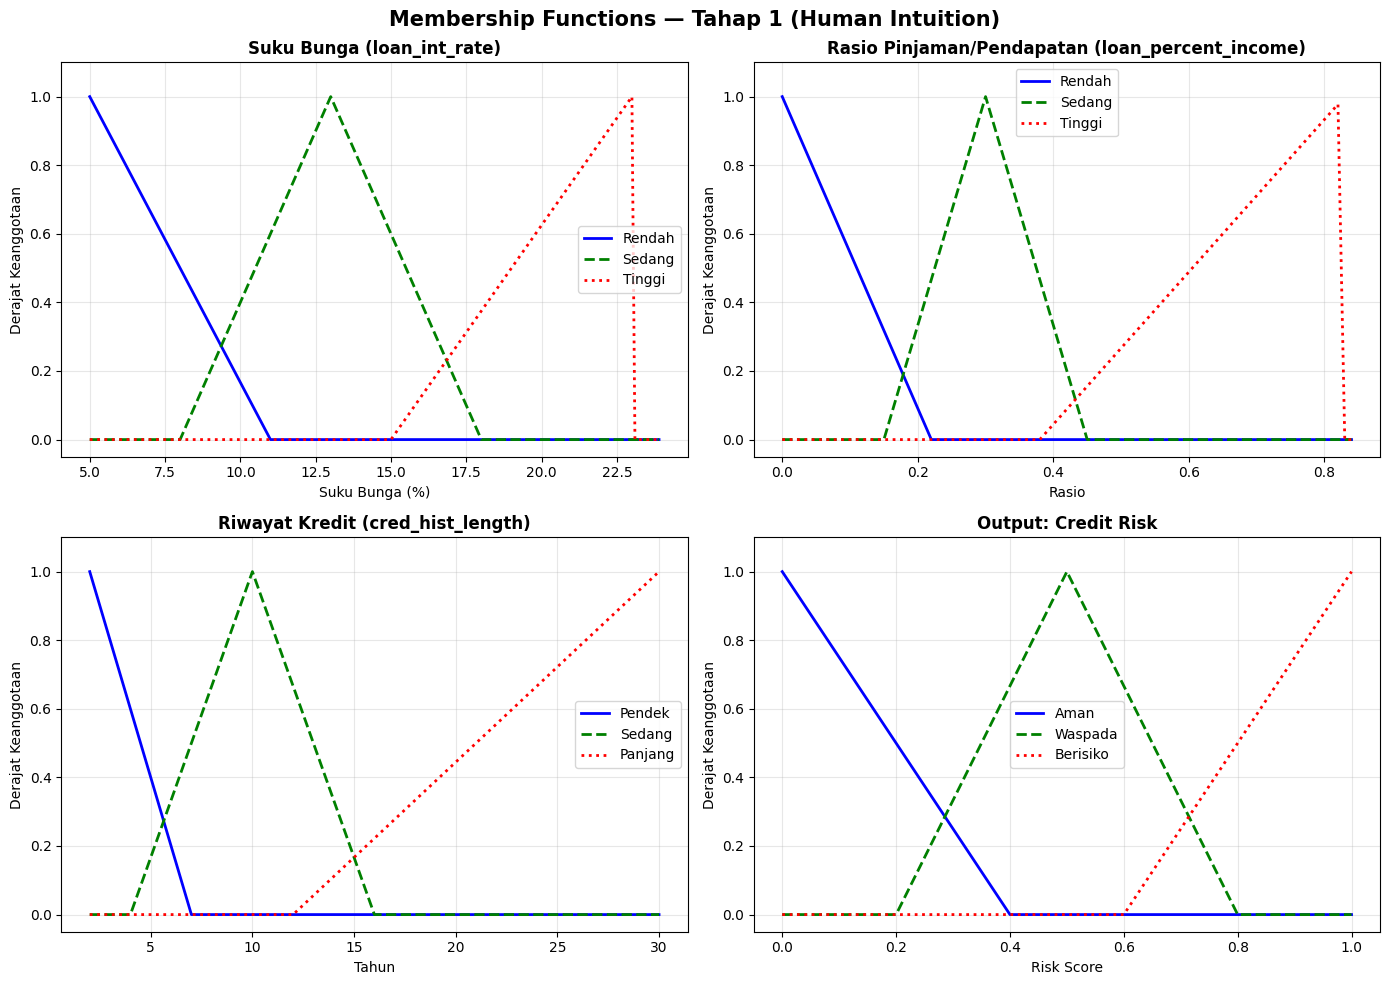

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Membership Functions — Tahap 1 (Human Intuition)', fontsize=15, fontweight='bold')

# Plot 1: Suku Bunga
ax = axes[0, 0]
ax.plot(x_int_rate, mf_rate_low,    'b-',  linewidth=2, label='Rendah')
ax.plot(x_int_rate, mf_rate_medium, 'g--', linewidth=2, label='Sedang')
ax.plot(x_int_rate, mf_rate_high,   'r:',  linewidth=2, label='Tinggi')
ax.set_title('Suku Bunga (loan_int_rate)', fontweight='bold')
ax.set_xlabel('Suku Bunga (%)')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Plot 2: Rasio Pinjaman/Pendapatan
ax = axes[0, 1]
ax.plot(x_pct_income, mf_pct_low,    'b-',  linewidth=2, label='Rendah')
ax.plot(x_pct_income, mf_pct_medium, 'g--', linewidth=2, label='Sedang')
ax.plot(x_pct_income, mf_pct_high,   'r:',  linewidth=2, label='Tinggi')
ax.set_title('Rasio Pinjaman/Pendapatan (loan_percent_income)', fontweight='bold')
ax.set_xlabel('Rasio')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Plot 3: Riwayat Kredit
ax = axes[1, 0]
ax.plot(x_cred_hist, mf_hist_short,  'b-',  linewidth=2, label='Pendek')
ax.plot(x_cred_hist, mf_hist_medium, 'g--', linewidth=2, label='Sedang')
ax.plot(x_cred_hist, mf_hist_long,   'r:',  linewidth=2, label='Panjang')
ax.set_title('Riwayat Kredit (cred_hist_length)', fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Plot 4: Output Risiko
ax = axes[1, 1]
ax.plot(x_risk, mf_risk_safe,    'b-',  linewidth=2, label='Aman')
ax.plot(x_risk, mf_risk_caution, 'g--', linewidth=2, label='Waspada')
ax.plot(x_risk, mf_risk_risky,   'r:',  linewidth=2, label='Berisiko')
ax.set_title('Output: Credit Risk', fontweight='bold')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig("../results/plots/mf_tahap1.png", dpi=150, bbox_inches='tight')
plt.show()

## Definisi Rules (Mamdani — Manual)

In [7]:
# ============================================================
# FUZZY RULES — Dibuat berdasarkan logika/intuisi manusia
# Format: IF [kondisi] THEN [output]
#
# Logika dasar:
# - Suku bunga tinggi               -> berisiko
# - Rasio cicilan/pendapatan tinggi -> berisiko
# - Riwayat kredit panjang          -> lebih aman
# ============================================================

rules = [
    # Rule 1-3: Suku bunga RENDAH
    {"rate": "low",    "pct": "low",    "hist": "long",   "risk": "safe"},
    {"rate": "low",    "pct": "low",    "hist": "medium", "risk": "safe"},
    {"rate": "low",    "pct": "low",    "hist": "short",  "risk": "caution"},
    {"rate": "low",    "pct": "medium", "hist": "long",   "risk": "safe"},
    {"rate": "low",    "pct": "medium", "hist": "medium", "risk": "caution"},
    {"rate": "low",    "pct": "medium", "hist": "short",  "risk": "caution"},
    {"rate": "low",    "pct": "high",   "hist": "long",   "risk": "caution"},
    {"rate": "low",    "pct": "high",   "hist": "medium", "risk": "risky"},
    {"rate": "low",    "pct": "high",   "hist": "short",  "risk": "risky"},

    # Rule 10-18: Suku bunga SEDANG
    {"rate": "medium", "pct": "low",    "hist": "long",   "risk": "safe"},
    {"rate": "medium", "pct": "low",    "hist": "medium", "risk": "caution"},
    {"rate": "medium", "pct": "low",    "hist": "short",  "risk": "caution"},
    {"rate": "medium", "pct": "medium", "hist": "long",   "risk": "caution"},
    {"rate": "medium", "pct": "medium", "hist": "medium", "risk": "caution"},
    {"rate": "medium", "pct": "medium", "hist": "short",  "risk": "risky"},
    {"rate": "medium", "pct": "high",   "hist": "long",   "risk": "caution"},
    {"rate": "medium", "pct": "high",   "hist": "medium", "risk": "risky"},
    {"rate": "medium", "pct": "high",   "hist": "short",  "risk": "risky"},

    # Rule 19-27: Suku bunga TINGGI
    {"rate": "high",   "pct": "low",    "hist": "long",   "risk": "caution"},
    {"rate": "high",   "pct": "low",    "hist": "medium", "risk": "caution"},
    {"rate": "high",   "pct": "low",    "hist": "short",  "risk": "risky"},
    {"rate": "high",   "pct": "medium", "hist": "long",   "risk": "caution"},
    {"rate": "high",   "pct": "medium", "hist": "medium", "risk": "risky"},
    {"rate": "high",   "pct": "medium", "hist": "short",  "risk": "risky"},
    {"rate": "high",   "pct": "high",   "hist": "long",   "risk": "risky"},
    {"rate": "high",   "pct": "high",   "hist": "medium", "risk": "risky"},
    {"rate": "high",   "pct": "high",   "hist": "short",  "risk": "risky"},
]

print(f"Total rules terdefinisi: {len(rules)} rules")
for i, r in enumerate(rules, 1):
    print(f"Rule {i:2d}: IF rate={r['rate']:6s} AND pct={r['pct']:6s} AND hist={r['hist']:6s} -> THEN risk={r['risk']}")

Total rules terdefinisi: 27 rules
Rule  1: IF rate=low    AND pct=low    AND hist=long   -> THEN risk=safe
Rule  2: IF rate=low    AND pct=low    AND hist=medium -> THEN risk=safe
Rule  3: IF rate=low    AND pct=low    AND hist=short  -> THEN risk=caution
Rule  4: IF rate=low    AND pct=medium AND hist=long   -> THEN risk=safe
Rule  5: IF rate=low    AND pct=medium AND hist=medium -> THEN risk=caution
Rule  6: IF rate=low    AND pct=medium AND hist=short  -> THEN risk=caution
Rule  7: IF rate=low    AND pct=high   AND hist=long   -> THEN risk=caution
Rule  8: IF rate=low    AND pct=high   AND hist=medium -> THEN risk=risky
Rule  9: IF rate=low    AND pct=high   AND hist=short  -> THEN risk=risky
Rule 10: IF rate=medium AND pct=low    AND hist=long   -> THEN risk=safe
Rule 11: IF rate=medium AND pct=low    AND hist=medium -> THEN risk=caution
Rule 12: IF rate=medium AND pct=low    AND hist=short  -> THEN risk=caution
Rule 13: IF rate=medium AND pct=medium AND hist=long   -> THEN risk=ca

## Fungsi Inferensi Mamdani (Manual)

In [8]:
def get_mf_value(variable, label, value):
    """Hitung derajat keanggotaan sebuah nilai terhadap MF tertentu."""
    if variable == "rate":
        mfs = {"low": mf_rate_low, "medium": mf_rate_medium, "high": mf_rate_high}
        return float(fuzz.interp_membership(x_int_rate, mfs[label], value))
    elif variable == "pct":
        mfs = {"low": mf_pct_low, "medium": mf_pct_medium, "high": mf_pct_high}
        return float(fuzz.interp_membership(x_pct_income, mfs[label], value))
    elif variable == "hist":
        mfs = {"short": mf_hist_short, "medium": mf_hist_medium, "long": mf_hist_long}
        return float(fuzz.interp_membership(x_cred_hist, mfs[label], value))

def mamdani_inference(rate_val, pct_val, hist_val):
    """
    Fuzzy Inference System — Mamdani
    Input  : nilai crisp suku bunga, rasio pinjaman, riwayat kredit
    Output : risk score crisp (0 = aman, 1 = berisiko)
    """
    output_mfs = {"safe": mf_risk_safe, "caution": mf_risk_caution, "risky": mf_risk_risky}
    aggregated  = np.zeros_like(x_risk)

    for rule in rules:
        # Fuzzifikasi & AND (min)
        mu_rate = get_mf_value("rate", rule["rate"], rate_val)
        mu_pct  = get_mf_value("pct",  rule["pct"],  pct_val)
        mu_hist = get_mf_value("hist", rule["hist"],  hist_val)
        firing_strength = min(mu_rate, mu_pct, mu_hist)

        if firing_strength > 0:
            # Clipping output MF
            clipped = np.fmin(firing_strength, output_mfs[rule["risk"]])
            # Agregasi (max)
            aggregated = np.fmax(aggregated, clipped)

    # Defuzzifikasi — Centroid
    if aggregated.max() == 0:
        return 0.5  # default jika tidak ada rule yang aktif
    risk_score = fuzz.defuzz(x_risk, aggregated, 'centroid')
    return risk_score

# Uji coba inferensi dengan 1 sampel
contoh_rate = 15.0  # suku bunga 15%
contoh_pct  = 0.35  # rasio 35%
contoh_hist = 4     # riwayat 4 tahun
hasil = mamdani_inference(contoh_rate, contoh_pct, contoh_hist)
print(f"Contoh inferensi:")
print(f"  Input  -> rate = {contoh_rate}%, pct = {contoh_pct}, hist = {contoh_hist} tahun")
print(f"  Output -> risk score = {hasil:.4f}")
print(f"  Label  -> {'Berisiko (default)' if hasil >= 0.5 else 'Aman (tidak default)'}")

Contoh inferensi:
  Input  -> rate = 15.0%, pct = 0.35, hist = 4 tahun
  Output -> risk score = 0.8514
  Label  -> Berisiko (default)


## Jalankan FIS ke Seluruh Dataset

In [9]:
THRESHOLD = 0.5

def mamdani_inference_batch(df_input):
    """batch dengan progress bar"""
    results = []
    output_mfs = {
        "safe":    mf_risk_safe,
        "caution": mf_risk_caution,
        "risky":   mf_risk_risky
    }

    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="FIS Inference"):
        aggregated = np.zeros_like(x_risk)

        for rule in rules:
            mu_rate = get_mf_value("rate", rule["rate"], row['loan_int_rate'])
            mu_pct  = get_mf_value("pct",  rule["pct"],  row['loan_percent_income'])
            mu_hist = get_mf_value("hist", rule["hist"],  row['cb_person_cred_hist_length'])
            firing  = min(mu_rate, mu_pct, mu_hist)

            if firing > 0:
                clipped    = np.fmin(firing, output_mfs[rule["risk"]])
                aggregated = np.fmax(aggregated, clipped)

        if aggregated.max() == 0:
            results.append(0.5)
        else:
            results.append(fuzz.defuzz(x_risk, aggregated, 'centroid'))

    return results

# Jalankan ke SELURUH data
print(f"Total data: {len(df_clean)} baris")
print("Mulai inferensi")

import time
start = time.time()

risk_scores = mamdani_inference_batch(df_clean)
df_clean['risk_score'] = risk_scores
df_clean['predicted']  = (df_clean['risk_score'] >= THRESHOLD).astype(int)  # ← pakai THRESHOLD

elapsed = time.time() - start
print(f"\nSelesai dalam {elapsed/60:.1f} menit!")
print(f"Distribusi prediksi:\n{df_clean['predicted'].value_counts()}")

Total data: 31677 baris
Mulai inferensi


FIS Inference: 100%|██████████| 31677/31677 [00:33<00:00, 952.89it/s] 


Selesai dalam 0.6 menit!
Distribusi prediksi:
predicted
1    22895
0     8782
Name: count, dtype: int64


## Evaluasi Performa

    EVALUASI TAHAP 1 — MANUAL FIS (MAMDANI)

Akurasi        : 43.73%

Classification Report:

                   precision    recall  f1-score   support

Tidak Default (0)       0.90      0.32      0.47     24852
      Default (1)       0.26      0.87      0.40      6825

         accuracy                           0.44     31677
        macro avg       0.58      0.59      0.44     31677
     weighted avg       0.76      0.44      0.46     31677



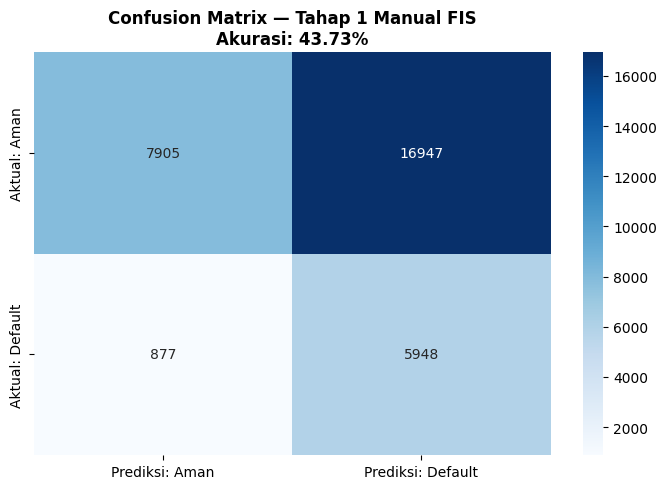

In [10]:
y_true = df_clean['loan_status']
y_pred = df_clean['predicted']

acc = accuracy_score(y_true, y_pred)

print("=" * 50)
print("    EVALUASI TAHAP 1 — MANUAL FIS (MAMDANI)")
print("=" * 50)
print(f"\nAkurasi        : {acc * 100:.2f}%")
print(f"\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Tidak Default (0)', 'Default (1)']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi: Aman', 'Prediksi: Default'],
            yticklabels=['Aktual: Aman', 'Aktual: Default'])
ax.set_title(f'Confusion Matrix — Tahap 1 Manual FIS\nAkurasi: {acc*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig("../results/confusion_matrix_tahap1.png", dpi=150, bbox_inches='tight')
plt.show()

## Distribusi Risk Score

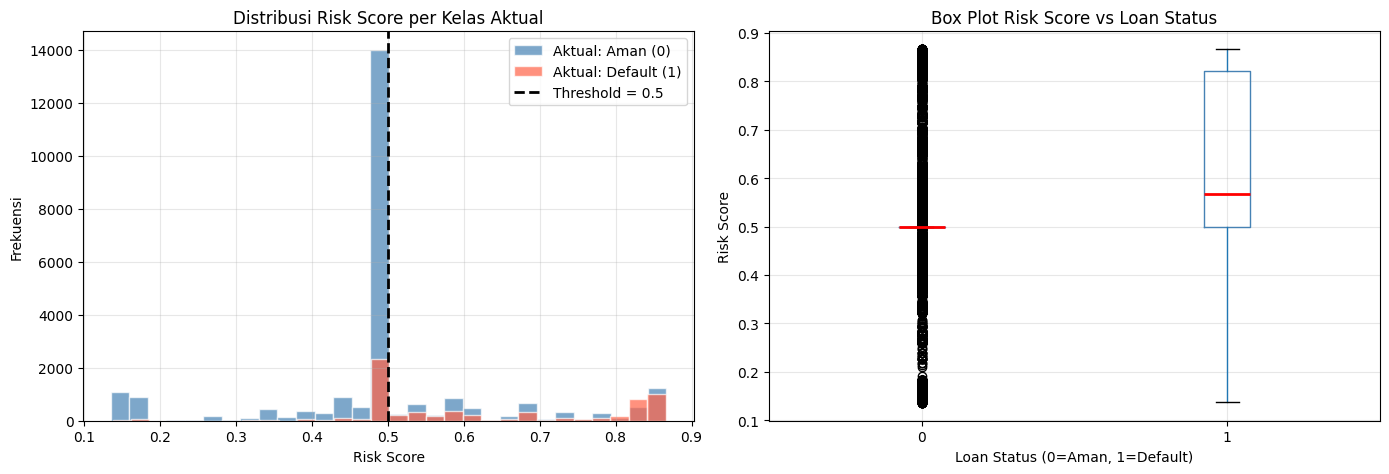

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Risk Score — Tahap 1 Manual FIS', fontsize=13, fontweight='bold')

# Plot 1: Histogram risk score per kelas
ax = axes[0]
ax.hist(df_clean[df_clean['loan_status']==0]['risk_score'], bins=30,
        alpha=0.7, color='steelblue', label='Aktual: Aman (0)', edgecolor='white')
ax.hist(df_clean[df_clean['loan_status']==1]['risk_score'], bins=30,
        alpha=0.7, color='tomato', label='Aktual: Default (1)', edgecolor='white')
ax.axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Risk Score per Kelas Aktual')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Box plot
ax = axes[1]
df_clean.boxplot(column='risk_score', by='loan_status', ax=ax,
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('Loan Status (0=Aman, 1=Default)')
ax.set_ylabel('Risk Score')
ax.set_title('Box Plot Risk Score vs Loan Status')
plt.suptitle('')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/risk_score_dist_tahap1.png', dpi=150, bbox_inches='tight')
plt.show()

## Simpan Hasil & Rekap Akhir

In [12]:
# Simpan hasil prediksi
df_clean.to_csv('../results/hasil_tahap1_manual_fis.csv', index=False)

# Rekap parameter MF (untuk dibandingkan di Tahap 2 setelah GA tuning)
mf_params_tahap1 = {
    "loan_int_rate": {
        "low":    [5,  5,  11],
        "medium": [8,  13, 18],
        "high":   [15, 23, 23]
    },
    "loan_percent_income": {
        "low":    [0.00, 0.00, 0.22],
        "medium": [0.15, 0.30, 0.45],
        "high":   [0.38, 0.83, 0.83]
    },
    "cb_person_cred_hist_length": {
        "short":  [2,  2,  7],
        "medium": [4,  10, 16],
        "long":   [12, 30, 30]
    }
}

with open('../results/mf_params_tahap1.json', 'w') as f:
    json.dump(mf_params_tahap1, f, indent=4)
print("Parameter MF disimpan ke 'mf_params_tahap1.json'")

print("=" * 55)
print("       REKAP AKHIR TAHAP 1 — MANUAL FIS")
print("=" * 55)
print(f"\n  Metode          : Mamdani FIS")
print(f"  Jumlah Input    : 3 variabel")
print(f"  Jumlah Rules    : {len(rules)} rules")
print(f"  Defuzzifikasi   : Centroid")
print(f"  Total data uji  : {len(df_clean)} data")
print(f"  Threshold       : {THRESHOLD}")
print(f"\n  >>> AKURASI TAHAP 1 : {acc * 100:.2f}% <<<")
print(f"\n  [!] Parameter MF di atas akan dioptimasi")
print(f"      oleh Algoritma Genetika pada Tahap 2.")
print("=" * 55)

print("\nFile tersimpan: 'hasil_tahap1_manual_fis.csv'")

Parameter MF disimpan ke 'mf_params_tahap1.json'
       REKAP AKHIR TAHAP 1 — MANUAL FIS

  Metode          : Mamdani FIS
  Jumlah Input    : 3 variabel
  Jumlah Rules    : 27 rules
  Defuzzifikasi   : Centroid
  Total data uji  : 31677 data
  Threshold       : 0.5

  >>> AKURASI TAHAP 1 : 43.73% <<<

  [!] Parameter MF di atas akan dioptimasi
      oleh Algoritma Genetika pada Tahap 2.

File tersimpan: 'hasil_tahap1_manual_fis.csv'
